# UNTR News Sentiment (Sectors + OpenAI)

This notebook:
1. Pulls recent news headlines mentioning **United Tractors (UNTR.JK)** from the [Sectors API](https://sectors.app)'s news endpoint.
2. Classifies each headline's sentiment (positive / negative) using the OpenAI (ChatGPT) API.
3. Saves the labeled headlines to CSV and shows a quick summary.

**Before running:**
- Get a Sectors API key at https://sectors.app (the news endpoint costs 1 API credit per request, up to 30 articles per call).
- Get an OpenAI API key at https://platform.openai.com/api-keys
- Either set them as environment variables (`SECTORS_API_KEY`, `OPENAI_API_KEY`) before launching Jupyter, or just run the "get API keys" cell below and paste them in when prompted -- they're kept in memory only for this session, never written into this notebook file.

In [ ]:
%pip install -q requests openai pandas matplotlib

In [1]:
import os
import time
import getpass
import requests
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI

In [ ]:
# Keys live in ../.env (gitignored); never paste a real key into a cell.
import sys
sys.path.append("../scripts")
from load_env import load_env
load_env()

SECTORS_API_KEY = os.environ.get("SECTORS_API_KEY") or getpass.getpass("Sectors API key: ")
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY") or getpass.getpass("OpenAI API key: ")

client = OpenAI(api_key=OPENAI_API_KEY)


# Step 1: Pull News Headlines from Sectors

Sectors' `GET /v2/news/` endpoint returns general IDX news, filterable by `symbols` (ticker) or a free-text `keyword`. We page through results with `limit`/`offset` until we've collected as many as we want or run out of pages.

Note: in Sectors' own sample responses, many articles carry an **empty `symbols` list** even when they're clearly about a specific company -- ticker tagging looks sparse. So we pull by ticker symbol *and* by keyword ("United Tractors") and merge the two, rather than trusting the ticker filter alone.

In [ ]:
SECTORS_BASE_URL = "https://api.sectors.app"
TICKER = "UNTR"          # Sectors uses the bare ticker, no ".JK" suffix
COMPANY_KEYWORD = "United Tractors"

def fetch_news(symbols=None, keyword=None, start=None, end=None, max_articles=100, page_size=30):
    """
    Pull news articles from the Sectors /v2/news/ endpoint, paging through
    results until either `max_articles` is reached or the API reports no
    more pages. Pass `symbols` (ticker) and/or `keyword` (free-text search).
    """
    headers = {"Authorization": SECTORS_API_KEY}
    articles = []
    offset = 0

    while len(articles) < max_articles:
        params = {
            "extension": "idx",
            "limit": min(page_size, 30),  # API max is 30 per page
            "offset": offset,
        }
        if symbols:
            params["symbols"] = symbols
        if keyword:
            params["keyword"] = keyword
        if start:
            params["start"] = start
        if end:
            params["end"] = end

        resp = requests.get(f"{SECTORS_BASE_URL}/v2/news/", headers=headers, params=params)
        if resp.status_code != 200:
            raise RuntimeError(f"Sectors API error {resp.status_code}: {resp.text}")

        payload = resp.json()
        results = payload.get("results", [])
        # We only ever classify/aggregate on the headline itself, so drop
        # the full article `body` right here -- it's the bulk of each
        # response's size and we never use it downstream.
        for r in results:
            r.pop("body", None)
        articles.extend(results)

        pagination = payload.get("pagination", {})
        if not pagination.get("has_next", False) or not results:
            break
        offset = pagination["next_offset"]

    return articles[:max_articles]

In [ ]:
by_symbol = fetch_news(symbols=TICKER, max_articles=100)
by_keyword = fetch_news(keyword=COMPANY_KEYWORD, max_articles=100)

print(f"By ticker symbol ({TICKER}): {len(by_symbol)} articles")
print(f"By keyword ({COMPANY_KEYWORD!r}): {len(by_keyword)} articles")

news_df = pd.concat([pd.DataFrame(by_symbol), pd.DataFrame(by_keyword)], ignore_index=True)

if not news_df.empty:
    news_df = news_df.drop(columns=["body"], errors="ignore")  # not needed downstream, and it's the bulk of each row
    news_df = news_df.drop_duplicates(subset="title").reset_index(drop=True)
    # format="mixed": the API returns ISO timestamps like "...T23:59:59",
    # but a CSV round-trip through pandas re-stringifies them as
    # "... 23:59:59" (space, not "T") -- once these get combined (in the
    # backfill step below) the column has both styles, which breaks a
    # fixed-format parse. "mixed" infers per-element instead of assuming
    # one format for the whole column.
    news_df["timestamp"] = pd.to_datetime(news_df["timestamp"], format="mixed")
    news_df = news_df.sort_values("timestamp").reset_index(drop=True)

print(f"\n{len(news_df)} unique articles after merging + de-duplicating by title")
news_df[["timestamp", "title", "source"]].tail(10) if not news_df.empty else news_df

## Backfill Earlier History

The pull above only reaches back to whatever `max_articles` happened to cover -- in practice, the last few months. To get a daily sentiment feature that actually has something to train on across the *whole* price history in `Stock UT pred.ipynb` (which starts 2025-09-01), we need news from further back too.

This backfills **2025-09-01 to 2026-05-30** (the earliest date the first pull already reached) and combines it with whatever was already pulled and saved to `data/news/UNTR/untr_news_raw.csv`, instead of re-pulling that recent window again.

**Cost note:** each Sectors request returns up to 30 articles and costs 1 API credit. A ~9-month window can need many pages -- `max_articles` below caps the spend; raise/lower it deliberately.

In [ ]:
BACKFILL_START = "2025-09-01"
BACKFILL_END = "2026-05-30"  # earliest date the first pull already reached

print(f"Pulling backfill articles ({BACKFILL_START} to {BACKFILL_END})...")
by_symbol_backfill = fetch_news(symbols=TICKER, start=BACKFILL_START, end=BACKFILL_END, max_articles=900)
by_keyword_backfill = fetch_news(keyword=COMPANY_KEYWORD, start=BACKFILL_START, end=BACKFILL_END, max_articles=900)

backfill_df = pd.concat([pd.DataFrame(by_symbol_backfill), pd.DataFrame(by_keyword_backfill)], ignore_index=True)
print(f"Backfill: {len(by_symbol_backfill)} by symbol, {len(by_keyword_backfill)} by keyword -> {len(backfill_df)} rows before dedup")

# Combine with whatever was already pulled (and possibly already
# classified) rather than re-spending API credits re-pulling the recent
# window again. Falls back to the in-memory `news_df` from the cell above
# only if nothing has been saved to disk yet.
existing_raw_path = "../data/news/UNTR/untr_news_raw.csv"
if os.path.exists(existing_raw_path):
    existing_df = pd.read_csv(existing_raw_path)
    print(f"Loaded {len(existing_df)} previously pulled articles from {existing_raw_path} (not re-pulling that range)")
else:
    existing_df = news_df.copy()

news_df = pd.concat([existing_df, backfill_df], ignore_index=True)
news_df = news_df.drop(columns=["body"], errors="ignore")  # drop any leftover body column from older pulls too
news_df = news_df.drop_duplicates(subset="title").reset_index(drop=True)
# format="mixed": existing_df's timestamps came back from a previous CSV
# round-trip ("... 23:59:59", space-separated), while backfill_df's are
# fresh from the API ("...T23:59:59", ISO with "T") -- the column now has
# both styles, so a fixed-format parse breaks. "mixed" infers per-element.
news_df["timestamp"] = pd.to_datetime(news_df["timestamp"], format="mixed")
news_df = news_df.sort_values("timestamp").reset_index(drop=True)

print(f"\nCombined total: {len(news_df)} unique articles, {news_df['timestamp'].min().date()} to {news_df['timestamp'].max().date()}")
news_df[["timestamp", "title", "source"]].head(10)

## Diagnostic: is this UNTR-specific, or does the archive not reach back that far at all?

The backfill above found almost nothing in `2025-09-01` to `2026-05-30`. Before concluding "Sectors has no UNTR history that far back," check whether the API has *any* IDX news at all in that window -- no ticker/keyword filter, just the date range.

In [ ]:
diag = fetch_news(start="2025-09-01", end="2026-05-30", max_articles=30)
print(f"Any general IDX news in that window (no ticker/keyword filter): {len(diag)}")
if diag:
    print(pd.DataFrame(diag)[["timestamp", "title"]].head(5))

**If `news_df` came back empty or very small:** double check the `TICKER`/`COMPANY_KEYWORD` spelling, widen the `start`/`end` date range (default has no lower bound, but worth checking), and confirm your Sectors API key has news access on your plan.

In [ ]:
os.makedirs("../data/news/UNTR", exist_ok=True)
news_df.to_csv("../data/news/UNTR/untr_news_raw.csv", index=False)
print(f"Saved {len(news_df)} articles to ../data/news/UNTR/untr_news_raw.csv")

In [9]:
SENTIMENT_MODEL = "gpt-4o-mini"  # cheap + fast; swap for whichever chat model you have access to

SENTIMENT_SYSTEM_PROMPT = (
    "You are a financial news sentiment classifier. Given a single news "
    "headline about a company, respond with exactly one word: "
    "'positive' if the headline is good news for the company/its stock, "
    "or 'negative' if it's bad news. If it reads as neutral or purely "
    "factual, still make your best-judgment call rather than refusing -- "
    "always answer with exactly one of those two words, nothing else."
)

def classify_sentiment(headline, retries=3):
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                model=SENTIMENT_MODEL,
                messages=[
                    {"role": "system", "content": SENTIMENT_SYSTEM_PROMPT},
                    {"role": "user", "content": headline},
                ],
                temperature=0,
                max_tokens=3,
            )
            label = resp.choices[0].message.content.strip().lower()
            if label in ("positive", "negative"):
                return label
            # Model didn't follow the format exactly -- take the best guess
            # rather than silently dropping the row.
            if "pos" in label:
                return "positive"
            if "neg" in label:
                return "negative"
            return "unclear"
        except Exception as e:
            if attempt == retries - 1:
                print(f"  Failed after {retries} attempts on {headline!r}: {e}")
                return "error"
            time.sleep(2 ** attempt)  # backoff: 1s, 2s, 4s

In [ ]:
# Reuse sentiment labels already saved from a previous run -- only spend
# OpenAI calls on genuinely new headlines (i.e. the backfill).
existing_sentiment_path = "../data/news/UNTR/untr_news_sentiment.csv"
if os.path.exists(existing_sentiment_path):
    labeled_lookup = pd.read_csv(existing_sentiment_path)[["title", "sentiment"]].drop_duplicates("title")
    news_df = news_df.merge(labeled_lookup, on="title", how="left")
else:
    news_df["sentiment"] = pd.NA

to_classify = news_df["sentiment"].isna()
print(f"{(~to_classify).sum()} headlines already labeled previously (reused, no API cost)")
print(f"{to_classify.sum()} new headlines to classify now")

todo_idx = news_df.index[to_classify]
for n, i in enumerate(todo_idx):
    news_df.loc[i, "sentiment"] = classify_sentiment(news_df.loc[i, "title"])
    if (n + 1) % 10 == 0 or n == len(todo_idx) - 1:
        print(f"Classified {n + 1}/{len(todo_idx)} new headlines")
    time.sleep(0.5)  # be polite to the rate limit

news_df[["timestamp", "title", "sentiment"]].tail(10)

In [ ]:
news_df.to_csv("../data/news/UNTR/untr_news_sentiment.csv", index=False)
print("Saved labeled headlines to ../data/news/UNTR/untr_news_sentiment.csv")

# Step 3: Quick Summary

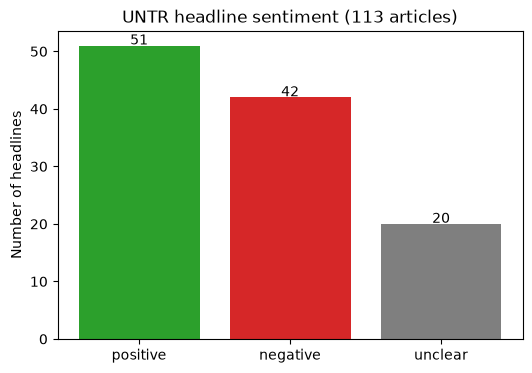

sentiment
positive    51
negative    42
unclear     20
Name: count, dtype: int64


In [12]:
counts = news_df["sentiment"].value_counts()

# Status colors, reserved for exactly this meaning -- not reused elsewhere,
# and never the only way the categories are told apart (the x-axis already
# labels each bar by name).
status_colors = {"positive": "#2ca02c", "negative": "#d62728", "unclear": "#7f7f7f", "error": "#bbbbbb"}
bar_colors = [status_colors.get(label, "#1f77b4") for label in counts.index]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=bar_colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.2, str(v), ha="center")
ax.set_title(f"UNTR headline sentiment ({len(news_df)} articles)")
ax.set_ylabel("Number of headlines")
plt.show()

print(counts)

## Caveats worth keeping in mind

- **LLM labels are opinions, not ground truth.** Spot-check a sample of headlines against their labels yourself before trusting them for anything downstream.
- **Small samples make the split noisy.** A 3-2 positive/negative split on 5 headlines says almost nothing; treat this like the RMSE baselines in the prediction notebook -- don't over-read small numbers.
- **Keyword search casts a wider net than it filters.** "United Tractors" can match unrelated mentions (e.g. other companies quoted alongside it); skim `news_df['title']` for relevance before trusting the whole set.
- **This costs real money/credits per run.** Each OpenAI call and each Sectors news request has a cost -- avoid re-running the classification loop unnecessarily once you have a saved CSV.
- **Natural next step:** aggregate this into a daily sentiment feature (e.g. net positive-minus-negative headline count per day) and add it into the `Stock UT pred.ipynb` return model as a new feature -- then test it against the baseline the same honest way we tested lag features and volume there, instead of assuming it will help.